In [1]:
from random import shuffle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import pickle
import json

In [2]:
df_false = pd.read_csv('../Fake.csv')

In [3]:
df_true = pd.read_csv("../True.csv")
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
df_false["label"] = 0
df_true["label"] = 1

In [5]:
df = pd.concat([df_false, df_true], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,MUST WATCH: SEN TED CRUZ Tells SEN BERNIE SAND...,Two US Senators who couldn t be more ideologic...,left-news,"Oct 19, 2017",0
1,BuzzFeed terminates Republican ad deal over Trump,NEW YORK (Reuters) - Online media outlet BuzzF...,politicsNews,"June 6, 2016",1
2,Macron: France ready to strengthen force in Sa...,PARIS (Reuters) - President Emmanuel Macron sa...,worldnews,"December 23, 2017",1
3,Professional Panderer Carly Fiorina Says Ted ...,Just days after forsaking her Stanford Cardina...,News,"January 3, 2016",0
4,Turkey denies 'ludicrous' reports of plan to s...,ISTANBUL (Reuters) - Turkey has dismissed what...,worldnews,"November 12, 2017",1


In [6]:
dups = df[df.duplicated(subset="title", keep=False)] \
        .sort_values(by=["title", "date"])

print(dups)

                                                   title  \
32573   McConnell Says He’ll Obstruct ANY Effort To H...   
16353   McConnell Says He’ll Obstruct ANY Effort To H...   
22886  #AnyoneButHillary: NEW POLL Shows Bernie Suppo...   
34128  #AnyoneButHillary: NEW POLL Shows Bernie Suppo...   
21421  #Austin: Fights Break Out Between Police and S...   
...                                                  ...   
27384  “Would You Rather Do A Job You Hate And Not Pa...   
795    “YOU’RE HIRED!” Trump Pulls Unemployed Vet Fro...   
41518  “YOU’RE HIRED!” Trump Pulls Unemployed Vet Fro...   
12621  “You’re Not Welcome!” Obama As Welcome At Rose...   
14085  “You’re Not Welcome!” Obama As Welcome At Rose...   

                                                    text          subject  \
32573  Siding with Trump s Attorney General Jeff Sess...             News   
16353  Siding with Trump s Attorney General Jeff Sess...             News   
22886  Hillary may find out she needs more than 

In [7]:
df_clean = df.drop_duplicates(subset = "title", keep = "first")
duplicates = df_clean[df_clean.duplicated(subset="title", keep=False)]
print(duplicates)

Empty DataFrame
Columns: [title, text, subject, date, label]
Index: []


In [8]:
X = df["title"].str.lower()
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Accuracy:  94.62138084632517


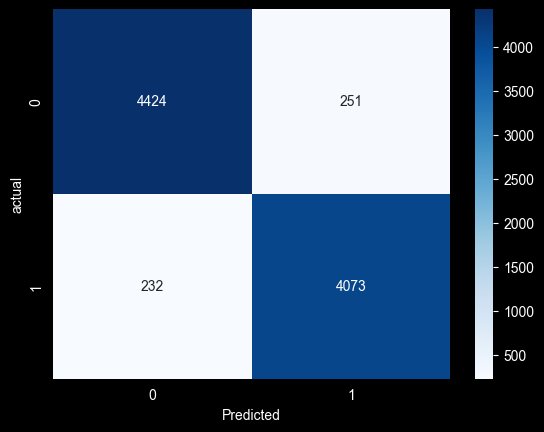

In [9]:
vectorizer = TfidfVectorizer(stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z]+\b', ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
model = LogisticRegression()
model.fit(X_train_vec,y_train_enc)
y_pred = model.predict(X_test_vec)
print("Accuracy: ", accuracy_score(y_test_enc, y_pred)*100)
accuracy = accuracy_score(y_test_enc, y_pred)*100;
metrics = {"accuracy": accuracy}
cm = confusion_matrix(y_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("actual")
plt.show()

In [10]:
#prediction_text = ["Jesus Clarifies shocking Return Will Be Strictly Limited To Carpentry Business"]
#new_text = vectorizer.transform(prediction_text)
#prediction_label = model.predict(new_text)
#print(prediction_label[0])

In [11]:
with open("../models/trained/model.pkl", "wb") as file:
    pickle.dump(model, file)
with open("../models/trained/vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)
with open("../models/artifacts/metrics.json", "w") as file:
    json.dump(metrics, file)